### Loading of dataset

dataset used: https://www.web-of-life.es/map.php?type=7
This dataset is from the web-of-life website. We are using the Forest animals of North Carolina, USA dataset

C:\Users\siahj\AppData\Local\Temp\ipykernel_29332\3503693177.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_palette = plt.cm.get_cmap('Set3', len(kingdoms))


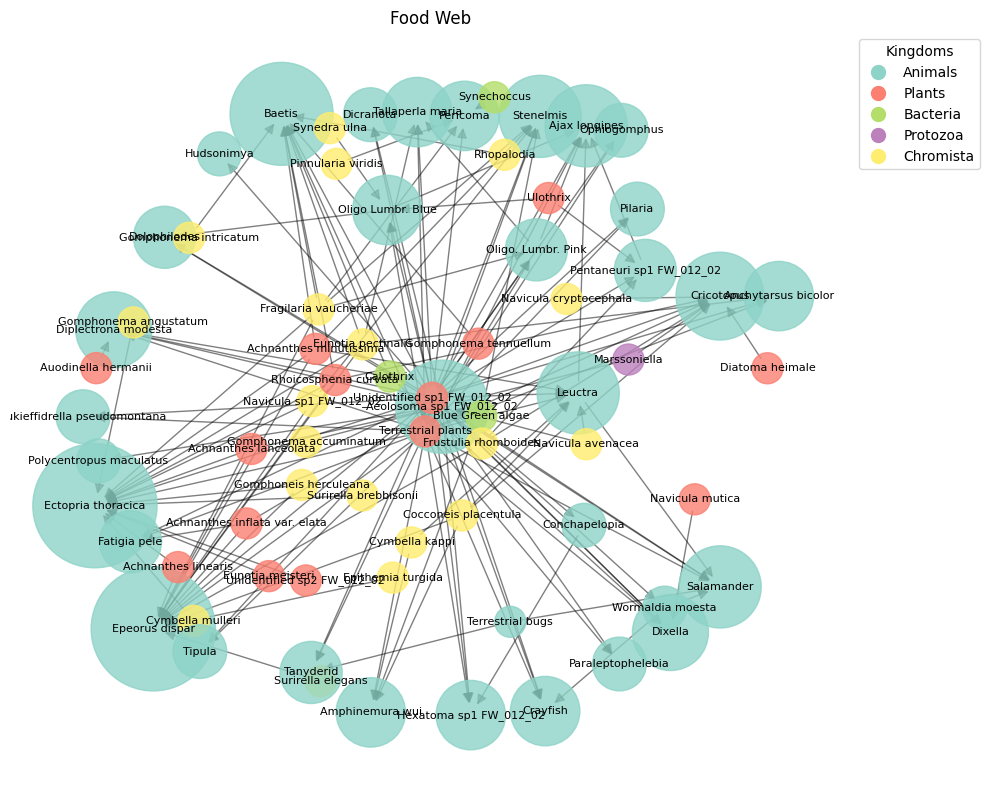

Nodes: 71
Edges: 148


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines

# 1. Load the CSV
df = pd.read_csv('data/FW_012_02.csv', index_col=0)
attributes_df = pd.read_csv('data/FW_012_02-species.csv')

# 2. Initialize a Directed Graph
G = nx.DiGraph()

# 3. Add edges based on the adjacency matrix
adj_matrix = df.values
prey_nodes = df.index.tolist()
predator_nodes = df.columns.tolist()

rows, cols = np.where(adj_matrix == 1)
edges = [(prey_nodes[r], predator_nodes[c]) for r, c in zip(rows, cols)]
G.add_edges_from(edges)


# 4. Kingdom mapping
kingdom_map = dict(zip(attributes_df['Specie'], attributes_df['Kingdom']))

for node in G.nodes():
    G.nodes[node]['Kingdom'] = kingdom_map.get(node, 'Unknown')

# Assign colors based on Kingdom
kingdoms = attributes_df['Kingdom'].unique()
colors_palette = plt.cm.get_cmap('Set3', len(kingdoms))
color_map_dict = {k: colors_palette(i) for i, k in enumerate(kingdoms)}

# Calculate node sizes based on in-degree (number of predators) + 1 to avoid zero size
node_sizes = [(G.in_degree(node) + 1) * 500 for node in G.nodes()]

# 5. Quick Visualization
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5)

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=[color_map_dict[G.nodes[node]['Kingdom']] for node in G.nodes()], alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5, arrows=True, arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=8)

# adding legend for the colormap
legend_handles = []
for kingdom, color in color_map_dict.items():
    # Create a circular marker for each kingdom
    handle = mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                          markersize=10, label=kingdom)
    legend_handles.append(handle)

# to show legend
plt.legend(handles=legend_handles, title="Kingdoms", loc='upper left', bbox_to_anchor=(1, 1))

plt.title("Food Web")
plt.axis('off')
# Adjusts layout so the legend isn't cut off
plt.tight_layout() 
plt.show()


# 5. Basic stats
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# Analysis of foodweb

### General statistics

1. Number of species in each kingdom
2. Top 5 species with the most out degree -- how many predators consume on that species
3. Top 5 species with the most in degree -- how many prey does the species consume, affect diversity of food source

In [8]:
print("number of species in each kingdom:")
for kingdom in kingdoms:
    count = sum(1 for k in G.nodes() if G.nodes[k]['Kingdom'] == kingdom)
    print(f"  {kingdom}: {count}")

number of species in each kingdom:
  Animals: 34
  Plants: 14
  Bacteria: 3
  Protozoa: 1
  Chromista: 19


In [9]:
print("Top 5 species by in-degree (most preyed upon):")
in_degrees = G.in_degree()
top_in_degree = sorted(in_degrees, key=lambda x: x[1], reverse=True)[:5]
for animal in top_in_degree:
    print(f"  {animal[0]}: {animal[1]} predators")

Top 5 species by in-degree (most preyed upon):
  Epeorus dispar: 15 predators
  Ectopria thoracica: 15 predators
  Baetis: 10 predators
  Aeolosoma sp1 FW_012_02: 8 predators
  Cricotopus: 7 predators


In [ ]:
in_degrees = G.in_degree()
total_in_degree = sum(deg for node, deg in in_degrees)
average_in_degree = total_in_degree / G.number_of_nodes()

print(f"Average in-degree (average number of predators per prey): {average_in_degree:.2f}")

Average in-degree (average number of predators per prey): 2.08


In [10]:
print("Top 5 predators by out-degree (most prey):")
out_degrees = G.out_degree()
top_out_degree = sorted(out_degrees, key=lambda x: x[1], reverse=True)[:5]
for animal in top_out_degree:
    print(f"  {animal[0]}: {animal[1]} prey")

Top 5 predators by out-degree (most prey):
  Unidentified sp1 FW_012_02: 32 prey
  Terrestrial plants: 22 prey
  Aeolosoma sp1 FW_012_02: 10 prey
  Fragilaria vaucheriae: 6 prey
  Achnanthes minutissima: 5 prey


In [22]:
out_degrees = G.out_degree()
total_out_degree = sum(deg for node, deg in out_degrees)
average_out_degree = total_out_degree / G.number_of_nodes()
print(f"Average out-degree (average number of prey per predator): {average_out_degree:.2f}")

Average out-degree (average number of prey per predator): 2.08


### Clustering Coefficient and Density

Clustering Coefficient of directed graph: 
- if a predator consumes a prey and another predator of that prey
- predator A eats predator B, B eats C and C eats A

Density: actual edges over all possible edges


reason for metric: Measure the interconnectedness of the Food web

In [ ]:
# dcitionary of local clustering coefficients for each node
directed_clustering = nx.clustering(G)

avg_directed_clustering = sum(directed_clustering.values()) / len(directed_clustering)
print(f"Directed Clustering Coefficient: {avg_directed_clustering:.4f}")


print("Density:", nx.density(G))

Directed Clustering Coefficient: 0.0535
Density: 0.02977867203219316


### Length of the food chains

how it is calculated: path from from a base species (only gets eaten) to a top predator (no other animals eat them)

reason for metric: if a species is removed how many other species will be affected is determined by the length of the path. The animals that are consumed by the species will likely increase and the predators that consume the species will likely decrease.

In [19]:
# Identify Basal Species (In-degree = 0) and Top Predators (Out-degree = 0)
basal_species = [n for n, d in G.in_degree() if d == 0]
top_predators = [n for n, d in G.out_degree() if d == 0]


for species in basal_species:
    print(f"Basal Species (In-degree = 0): {species}")
print("number of basal species:", len(basal_species))


for species in top_predators:
    print(f"Top Predator (Out-degree = 0): {species}")
print("number of top predators:", len(top_predators))

Basal Species (In-degree = 0): Achnanthes inflata var. elata
Basal Species (In-degree = 0): Achnanthes lanceolata
Basal Species (In-degree = 0): Achnanthes linearis
Basal Species (In-degree = 0): Achnanthes minutissima
Basal Species (In-degree = 0): Auodinella hermanii
Basal Species (In-degree = 0): Blue Green algae
Basal Species (In-degree = 0): Calothrix
Basal Species (In-degree = 0): Cocconeis placentula
Basal Species (In-degree = 0): Cymbella kappi
Basal Species (In-degree = 0): Cymbella mulleri
Basal Species (In-degree = 0): Diatoma heimale
Basal Species (In-degree = 0): Epithemia turgida
Basal Species (In-degree = 0): Eunotia meisteri
Basal Species (In-degree = 0): Eunotia pectinalis
Basal Species (In-degree = 0): Fragilaria vaucheriae
Basal Species (In-degree = 0): Frustulia rhomboides
Basal Species (In-degree = 0): Gomphoneis herculeana
Basal Species (In-degree = 0): Gomphonema accuminatum
Basal Species (In-degree = 0): Gomphonema angustatum
Basal Species (In-degree = 0): Gomph

In [20]:
food_chain_lengths = []

for start in basal_species:
    for end in top_predators:
        if nx.has_path(G, start, end):
            # Shortest path from this plant to this predator
            path_len = nx.shortest_path_length(G, start, end)
            food_chain_lengths.append(path_len)

# print(f"Food Chain Lengths: {food_chain_lengths}")
print(f"Average Food Chain Length: {sum(food_chain_lengths)/len(food_chain_lengths):.2f}")

Average Food Chain Length: 1.44


### Jaccard index

Jaccard Index: ratio of shared prey to the total unique prey both predators eat combined.
- = 1.0 when 2 predators share the same prey
- = 0 when 2 predator do not share the same prey

reason for calculating: 
- competition for the same food source
- how affected will the ecosystem be when a prey is extinct

Average Dietary Overlap (Jaccard Index) across all predator pairs: 0.2723


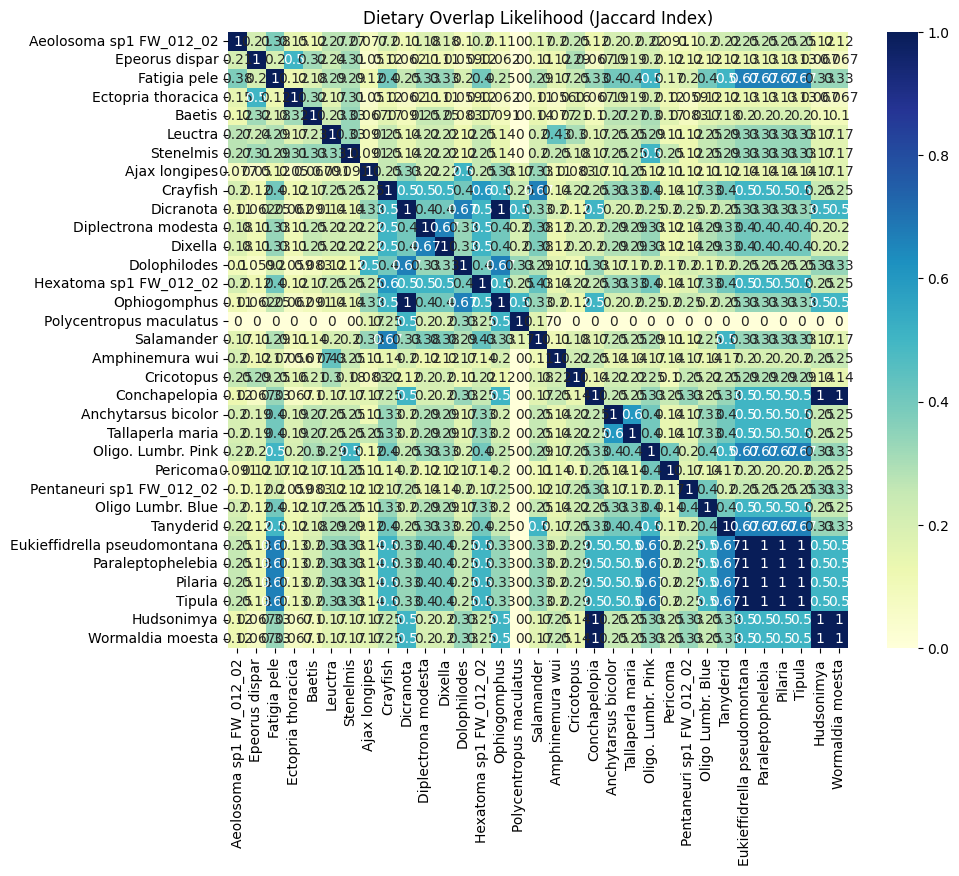

In [28]:
import seaborn as sns

# Get list of all predators (nodes with in-degree > 0)
preds = [n for n in G.nodes() if G.in_degree(n) > 0]
matrix_size = len(preds)
overlap_matrix = pd.DataFrame(index=preds, columns=preds, dtype=float)

total_overlaps = 0
total_pairs = 0

def jaccard_index(G, pred1, pred2):
    global total_overlaps, total_pairs
    
    prey1 = set(G.predecessors(pred1))
    prey2 = set(G.predecessors(pred2))
    
    if not prey1 and not prey2:
        return 0.0 # Both are likely basal species
        
    intersection = len(prey1.intersection(prey2))
    union = len(prey1.union(prey2))
    
    if pred1 != pred2:
        total_overlaps += intersection/union
        total_pairs += 1
    
    return intersection / union

for p1 in preds:
    for p2 in preds:
        overlap_matrix.loc[p1, p2] = jaccard_index(G, p1, p2)

print(f"Average Dietary Overlap (Jaccard Index) across all predator pairs: {total_overlaps/total_pairs:.4f}")

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, cmap="YlGnBu")
plt.title("Dietary Overlap Likelihood (Jaccard Index)")
plt.show()